In [15]:
from pathlib import Path
import json
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim

import numpy as np
from tqdm import tqdm

In [16]:
%reload_ext tensorboard
%tensorboard --logdir ../runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/home/chris/miniconda3/envs/ramenv/bin/tensorboard", line 6, in <module>
    from tensorboard.main import run_main
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

In [17]:
rows, cols = 64, 64

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DATA_DIR = Path("../data/dataset2-master/dataset2-master/images")
TENSORBOARD_LOG_DIR = Path("../runs/lenet_original")
TENSORBOARD_LOG_DIR.mkdir(parents=True, exist_ok=True)

TENSORBOARD_BN_LOG_DIR = Path("../runs/lenet_bn")
TENSORBOARD_BN_LOG_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("../results")
HISTORY_DIR = RESULTS_DIR / "histories"
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

train_dir = DATA_DIR / "TRAIN"
test_dir = DATA_DIR / "TEST"

In [18]:
transform = transforms.Compose([
    transforms.Resize((rows, cols)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train = datasets.ImageFolder(train_dir, transform=transform)
test = datasets.ImageFolder(test_dir, transform=transform)

In [19]:
BATCH_SIZE = 32
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
import sys
from pathlib import Path

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from models.lenet import LeNet, LeNetBN

In [21]:
def train(model, device, train_loader, optimizer, criterion, epoch, writer=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Training epoch {epoch}")
    for batch_idx, (data, target) in progress_bar:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        batch_loss = loss.item()
        running_loss += batch_loss * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        batch_acc = correct / total
        global_step = (epoch - 1) * len(train_loader) + batch_idx
        
        progress_bar.set_postfix(loss=batch_loss, acc=batch_acc)
        if writer is not None:
            writer.add_scalar("Loss/train_batch", batch_loss, global_step)
            writer.add_scalar("Accuracy/train_batch", batch_acc, global_step)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    if writer is not None:
        writer.add_scalar("Loss/train_epoch", epoch_loss, epoch)
        writer.add_scalar("Accuracy/train_epoch", epoch_acc, epoch)
    return epoch_loss, epoch_acc


def evaluate(model, device, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def new_history(model_name):
    return {
        "model": model_name,
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
    }


def append_history(history, epoch, train_loss, train_acc, test_loss, test_acc):
    history["epoch"].append(int(epoch))
    history["train_loss"].append(float(train_loss))
    history["test_loss"].append(float(test_loss))
    history["train_acc"].append(float(train_acc))
    history["test_acc"].append(float(test_acc))


def save_history(history, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(history, indent=2), encoding="utf-8")


def load_history(path):
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}. Ejecuta primero las celdas de entrenamiento para generar el history.")
    return json.loads(path.read_text(encoding="utf-8"))


def history_metric(history, key):
    return history["epoch"], history[key]

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_original = LeNet(num_classes=4)
model_original.to(device)

LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_original.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
writer = SummaryWriter(log_dir=str(TENSORBOARD_LOG_DIR))

cuda


In [23]:
EPOCHS = 10
history_original = new_history("LeNet")

try:
    sample_images, _ = next(iter(train_loader))
    writer.add_graph(model_original, sample_images.to(device))
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_original, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_original, device, test_loader, criterion)
    append_history(history_original, epoch, train_loss, train_acc, test_loss, test_acc)

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
save_history(history_original, HISTORY_DIR / "lenet_original_history.json")
torch.save(model_original.state_dict(), "../models/lenet_original.pth")

Training epoch 1: 100%|██████████| 312/312 [00:09<00:00, 33.64it/s, acc=0.285, loss=1.55]


Epoch 1/10 - train_loss: 1.3779 - train_acc: 0.2853 - test_loss: 1.3583 - test_acc: 0.2517


Training epoch 2: 100%|██████████| 312/312 [00:08<00:00, 35.32it/s, acc=0.367, loss=1.35]


Epoch 2/10 - train_loss: 1.3011 - train_acc: 0.3673 - test_loss: 1.1835 - test_acc: 0.3852


Training epoch 3: 100%|██████████| 312/312 [00:08<00:00, 35.69it/s, acc=0.444, loss=1.16] 


...

Epoch 8/10 - train_loss: 0.6897 - train_acc: 0.6917 - test_loss: 1.3466 - test_acc: 0.4873


Training epoch 9: 100%|██████████| 312/312 [00:09<00:00, 34.41it/s, acc=0.711, loss=0.746]


Epoch 9/10 - train_loss: 0.6495 - train_acc: 0.7111 - test_loss: 0.9599 - test_acc: 0.5822


Training epoch 10: 100%|██████████| 312/312 [00:09<00:00, 34.50it/s, acc=0.753, loss=0.262]


Epoch 10/10 - train_loss: 0.5604 - train_acc: 0.7533 - test_loss: 1.3041 - test_acc: 0.5167


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_bn = LeNetBN(num_classes=4)
model_bn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_bn.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
writer = SummaryWriter(log_dir=str(TENSORBOARD_BN_LOG_DIR))

cuda


In [25]:
EPOCHS = 10
history_bn = new_history("LeNetBN")

try:
    sample_images, _ = next(iter(train_loader))
    writer.add_graph(model_bn, sample_images.to(device))
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_bn, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_bn, device, test_loader, criterion)
    append_history(history_bn, epoch, train_loss, train_acc, test_loss, test_acc)

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
save_history(history_bn, HISTORY_DIR / "lenet_bn_history.json")
torch.save(model_bn.state_dict(), "../models/lenet_bn.pth")

Training epoch 1: 100%|██████████| 312/312 [00:09<00:00, 33.58it/s, acc=0.412, loss=0.807]


Epoch 1/10 - train_loss: 1.2569 - train_acc: 0.4118 - test_loss: 1.7270 - test_acc: 0.3040


Training epoch 2: 100%|██████████| 312/312 [00:09<00:00, 33.58it/s, acc=0.57, loss=0.558] 


Epoch 2/10 - train_loss: 0.9799 - train_acc: 0.5704 - test_loss: 1.5910 - test_acc: 0.3474


Training epoch 3: 100%|██████████| 312/312 [00:09<00:00, 33.52it/s, acc=0.704, loss=0.787]


...

Epoch 8/10 - train_loss: 0.1902 - train_acc: 0.9307 - test_loss: 3.1528 - test_acc: 0.3788


Training epoch 9: 100%|██████████| 312/312 [00:10<00:00, 31.04it/s, acc=0.937, loss=0.0773]


Epoch 9/10 - train_loss: 0.1689 - train_acc: 0.9374 - test_loss: 2.6356 - test_acc: 0.3924


Training epoch 10: 100%|██████████| 312/312 [00:09<00:00, 31.82it/s, acc=0.967, loss=1.18]  


Epoch 10/10 - train_loss: 0.0982 - train_acc: 0.9669 - test_loss: 3.4244 - test_acc: 0.3663


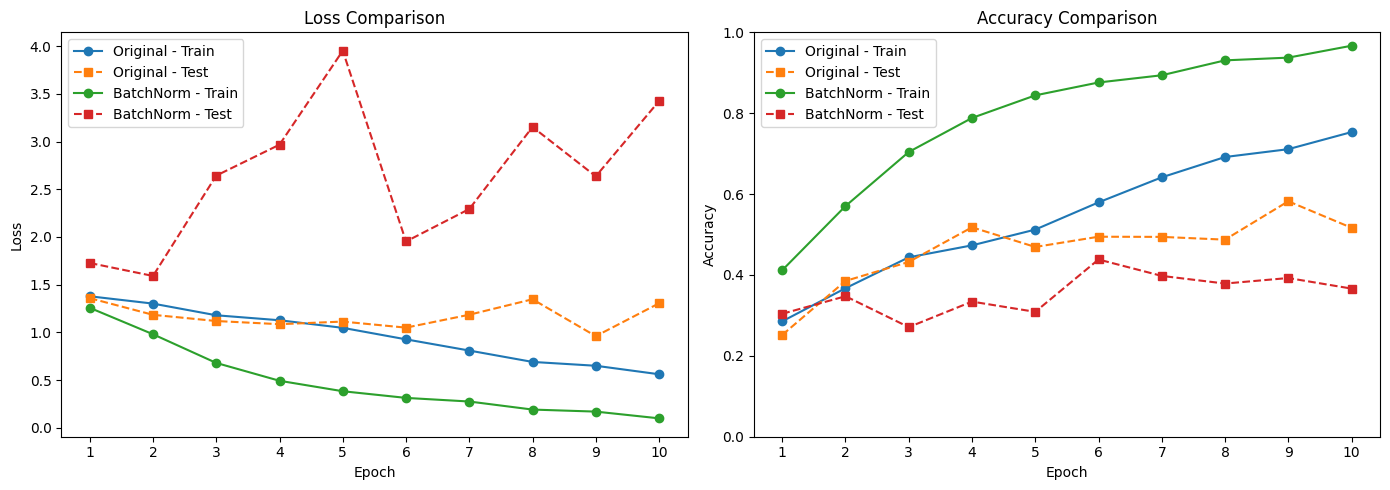

In [26]:
import matplotlib.pyplot as plt

histories = [
    (load_history(HISTORY_DIR / "lenet_original_history.json"), "Original"),
    (load_history(HISTORY_DIR / "lenet_bn_history.json"), "BatchNorm"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for history, label in histories:
    epochs = history["epoch"]
    axes[0].plot(epochs, history["train_loss"], linestyle="-", marker="o", label=f"{label} - Train")
    axes[0].plot(epochs, history["test_loss"], linestyle="--", marker="s", label=f"{label} - Test")
    axes[1].plot(epochs, history["train_acc"], linestyle="-", marker="o", label=f"{label} - Train")
    axes[1].plot(epochs, history["test_acc"], linestyle="--", marker="s", label=f"{label} - Test")

axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_xticks(histories[0][0]["epoch"])
axes[0].legend()

axes[1].set_title("Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(histories[0][0]["epoch"])
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()